# 02 — Debug Model Forward Pass

Runs a full forward pass on CPU (torch 2.2.2+cpu) to verify all wiring is intact before training.
Images are capped at 320 px and num_queries is reduced to 10 for speed.

> **Expected benign warning:** `PyTorch was not found. Models won't be available …`  
> This is noise from a HuggingFace tokenizers side-import. Safe to ignore.

## 0 — sys.path + imports

In [1]:
import sys, os
from pathlib import Path

ROOT = Path(os.getcwd()).parent  # notebooks/ lives one level below project root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)

ROOT: /home/gutenbye/Documents/UIT/Semester_2/NMAI/priv_proj


In [2]:
import torch
print('torch version :', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
DEVICE = 'cpu'

torch version : 2.2.2+cpu
CUDA available: False


## 1 — Config

In [3]:
from omegaconf import OmegaConf

cfg = OmegaConf.load(ROOT / 'configs' / 'default.yaml')
cfg.data.max_size      = 320   # smaller = faster on CPU
cfg.model.num_queries  = 10    # fewer queries, still exercises all paths

print(OmegaConf.to_yaml(cfg))

model:
  backbone:
    name: resnet50
    pretrained: true
    freeze_at: 1
    out_indices:
    - 1
    - 2
    - 3
  neck:
    out_channels: 256
    num_levels: 4
  transformer:
    d_model: 256
    nhead: 8
    num_encoder_layers: 6
    num_decoder_layers: 6
    dim_feedforward: 2048
    dropout: 0.1
  num_classes: 356
  num_queries: 10
  aux_loss: true
data:
  ann_file: data/raw/coco_dataset/train/annotations.json
  img_dir: data/raw/coco_dataset/train/images
  max_size: 320
  num_workers: 4
  batch_size: 2
  val_split: 0.2
  seed: 42
training:
  max_epochs: 50
  base_lr: 0.0001
  backbone_lr: 1.0e-05
  weight_decay: 0.0001
  grad_clip: 0.1
  lr_milestones:
  - 40
  lr_gamma: 0.1
  focal_alpha: 0.25
  focal_gamma: 2.0
  matcher:
    cost_class: 2.0
    cost_bbox: 5.0
    cost_giou: 2.0
  loss_weights:
    loss_ce: 2.0
    loss_bbox: 5.0
    loss_giou: 2.0
  checkpoint_dir: models/checkpoints
  log_every_n_steps: 10
inference:
  threshold: 0.3
  nms_threshold: 0.5
  top_k: 300
  dev

## 2 — Dataset + DataLoader

In [4]:
from torch.utils.data import DataLoader
from training.dataset import COCODetectionDataset, collate_fn
from training.transforms import get_train_transforms

ds = COCODetectionDataset(
    ann_file=str(ROOT / cfg.data.ann_file),
    img_dir =str(ROOT / cfg.data.img_dir),
    transforms=get_train_transforms(cfg.data.max_size),
    # max_size removed — resizing is done inside the transform pipeline
)
print(f'Dataset size        : {len(ds)}')
print(f'Number of categories: {len(ds.cat_id_to_idx)}')

loader = DataLoader(ds, batch_size=2, shuffle=False,
                    num_workers=0, collate_fn=collate_fn)
batch   = next(iter(loader))
images  = batch['images']   # (B, 3, H, W)
masks   = batch['masks']    # (B, H, W) — False=valid, True=padded
targets = batch['targets']

print('images :', tuple(images.shape))
print('masks  :', tuple(masks.shape))
print('mask convention — top-left should be False (valid):',
      bool(masks[0, 0, 0] == False))

/home/gutenbye/Documents/UIT/Semester_2/NMAI/priv_proj/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Dataset size        : 248
Number of categories: 356
images : (2, 3, 256, 320)
masks  : (2, 256, 320)
mask convention — top-left should be False (valid): True


## 3 — Visualise sample + GT boxes

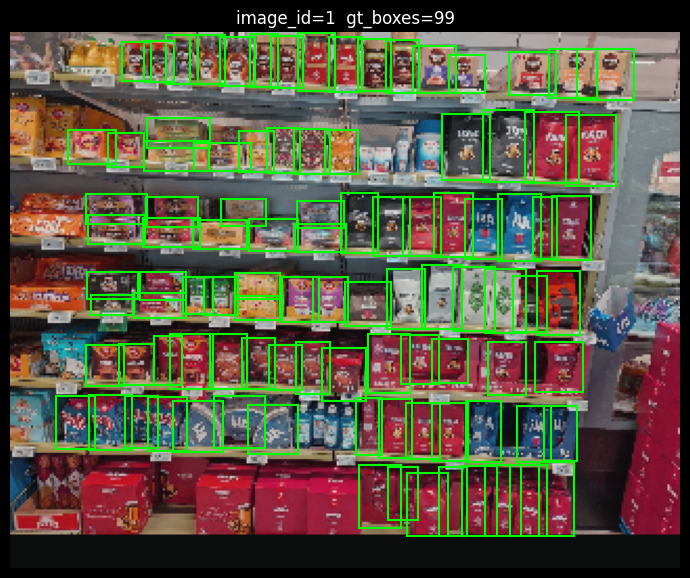

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

img_np = images[0].permute(1, 2, 0).numpy()
img_np = np.clip(img_np * STD + MEAN, 0, 1)
H, W   = img_np.shape[:2]

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img_np)
# Box convention: dataset returns normalised cx/cy/w/h
# Convert to pixel x1/y1 for matplotlib Rectangle
for box in targets[0]['boxes']:
    cx, cy, bw, bh = box.tolist()
    x1, y1 = (cx - bw / 2) * W, (cy - bh / 2) * H
    ax.add_patch(patches.Rectangle(
        (x1, y1), bw * W, bh * H,
        linewidth=1.5, edgecolor='lime', facecolor='none'))
ax.set_title(f"image_id={targets[0]['image_id']}  "
             f"gt_boxes={len(targets[0]['boxes'])}")
plt.axis('off'); plt.tight_layout(); plt.show()

## 4 — Build model

In [6]:
# May print: 'PyTorch was not found. Models won't be available …'  ← benign
from models.groundingdino.model import build_model

model = build_model(cfg.model).to(DEVICE)
model.eval()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2+cpu
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


ConfigAttributeError: Missing key model
    full_key: model.model
    object_type=dict

## 5 — Sub-module probe (backbone → FPN → pos_embed)

In [ ]:
x = images[:1].to(DEVICE)

with torch.no_grad():
    feats = model.backbone(x)
    print('Backbone outputs:')
    for i, f in enumerate(feats):
        print(f'  level {i}: {tuple(f.shape)}')

    fpn_feats = model.neck(feats)
    print('FPN outputs:')
    for i, f in enumerate(fpn_feats):
        print(f'  level {i}: {tuple(f.shape)}')

    projected = model.input_proj[0](fpn_feats[0])
    print('Projected level-0:', tuple(projected.shape))

    # Call pos_embed with 1 arg (mask is optional after Fix #1)
    pos = model.pos_embed(projected)
    print('pos_embed output  :', tuple(pos.shape))

## 6 — Full forward pass

In [ ]:
with torch.no_grad():
    outputs = model(images.to(DEVICE), masks.to(DEVICE))

B, Q, C = outputs['pred_logits'].shape
print('pred_logits :', tuple(outputs['pred_logits'].shape))
print('pred_boxes  :', tuple(outputs['pred_boxes'].shape))
if 'aux_outputs' in outputs:
    print(f'aux_outputs : {len(outputs["aux_outputs"])} layers')

assert C == cfg.model.num_classes, f'class dim mismatch: {C}'
assert Q == cfg.model.num_queries, f'query dim mismatch: {Q}'
boxes = outputs['pred_boxes']
assert boxes.shape == (B, Q, 4)
assert boxes.min() >= 0.0 and boxes.max() <= 1.0, 'boxes not in [0,1]'
print('\n✓ Forward pass shape checks passed.')

## 7 — Loss

In [ ]:
from training.losses import build_criterion

criterion = build_criterion(cfg)
with torch.no_grad():
    loss_dict = criterion(outputs, targets)

for k, v in loss_dict.items():
    print(f'  {k}: {v.item():.4f}')
total = sum(loss_dict.values())
print(f'Total loss: {total.item():.4f}')
assert total.item() > 0, 'Total loss is zero — something is wrong.'
print('\n✓ Loss computation OK.')

## 8 — Reference points sanity check

In [ ]:
ref = model.reference_points.weight.data
print(f'shape: {tuple(ref.shape)}  min: {ref.min():.4f}  max: {ref.max():.4f}')
assert ref.min() >= 0.04 and ref.max() <= 0.96, \
    'Reference points outside [0.05, 0.95]!'
print('✓ Reference points within [0.05, 0.95].')

## 9 — Summary

In [ ]:
print('=== Debug Summary ===')
print(f'  Batch          : {tuple(images.shape)}')
print(f'  pred_logits    : {tuple(outputs["pred_logits"].shape)}')
print(f'  pred_boxes     : {tuple(outputs["pred_boxes"].shape)}')
print(f'  Total loss     : {total.item():.4f}')
print(f'  Aux layers     : {len(outputs.get("aux_outputs", []))}')
print()
print('All checks passed — model is ready for training.')